# Importing

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
#--------------- IMPORTING FROM FILES ---------------#
currentdir = os.getcwd()
parentdir = os.path.dirname(currentdir)
#--------------- FILES PARENTDIR ---------------#
sys.path.insert(0, parentdir)
from NFW_class import NFW_profile, r1
from Isothermal_paper_2206 import findTwoDeltaMinimum, findTwoDeltaMinimum_vol2
import Config as cfg  # helpfull functions and constans
import AuxiliaryFunctions as aux

# SETS OF SIMULATION: USER SETS!

In [2]:
# annihilation cross-section
sigma_m = 1.0  # [cm^2/g]
sigma_m_SI = sigma_m * 10 ** (-4) * 10 ** 3  # [m^2/kg]
# Viral mass
M_vir = 10 ** 11.04  # [M_sun]
# concentration of DM
const_c = 15.2  # dimensionless

# Evolution time of galaxy
tage_grid = np.logspace(-5 * 0.1, 2.5, 50)  # [Gyr] # for c = 15.2, sigma_m = 1.0, M_vir = 10**11.04
# tage_grid = np.logspace(-1.0, 2.4, 49)  #[Gyr] # for c = 15, sigma_m = 5.0, M_vir = 10**9.32 # [M_sun]
# print('time_evolution [Gyr]', tage_grid)

# ----------------------------------------------
# If you want to add special value of time just uncomment
# tage_to_plot = [2.0,10.0,50.0,100.0, 200.0, 250.0, 280.0]
# for times in tage_to_plot:
#     tage_grid = np.append(tage_grid, times)
# tage_grid.sort()
# print(tage_grid)
# -----------------------------------------------
# how many times we set
diff_tim = len(tage_grid)

# CREATING NFW CLASS

In [3]:
NFW_profile = NFW_profile(M_vir, const_c)
r_s = NFW_profile.r_s
rounded_r_s = cfg.rounded_number(r_s, 3)

rho_s = NFW_profile.rho_s
rounded_rho_s = cfg.rounded_number(rho_s, 3)
print(f"rho_s = {rounded_rho_s} [M_solar / kpc^3], r_s = {rounded_r_s} [kpc]")

rho_s = 17700000.0 [M_solar / kpc^3], r_s = 6.43 [kpc]


# LOOP FOR EVERY TIME: USER SETS!

In [4]:
nums_r = 600  # for how many radius we want data in .txt  file
r = np.logspace(-0.5, 2.5, nums_r)  # radius: 500 for -2., 2.

r1marge = 0  # [kpc], value of r1 when merging occurs
tmarge = 0  # merging time in [Gyr]
merged_appear = False  # flag to find the first time when physical and unphysical have comparable values

rel_err_margin = 1.0 # when mergin appers

In [5]:
for time in range(0, diff_tim):
    ####################### BASIC VARAIBLES #######################
    # selected time
    tage = tage_grid[time]  # [Gyr]
    # simulation parameters
    sim_parms = [M_vir, const_c, sigma_m, tage]

    # -------------- FINDING R1 OF OUR PROFILE --------------#
    # new one way to get r1
    r_1 = r1(NFW_profile, sigmamx=sigma_m, tage=tage)
    # rounded_r1 = cfg.rounded_number(r_1, 5)
    # print("potential r_1:", potential_r_1)
    # print(f"r_1 = {rounded_r1} [kpc]")

    ####################### ISOTHERMAL #######################
    # Isothermal: low dense, high dense
    SIDM_LoDens, SIDM_HiDens = findTwoDeltaMinimum(r_1, NFW_profile)  # by default r_low=-3.
    # SIDM_LoDens, SIDM_HiDens = findTwoDeltaMinimum(r_1, NFW_profile, r_low=-2.)

    ####################### SAVE NECESSARY DATA #######################
    # find the density values
    rhodm0_LoDens = SIDM_LoDens[0]  # [M_sun/kpc^3]
    rhodm0_HiDens = SIDM_HiDens[0]  # [M_sun/kpc^3]

    # ---------------------- SEARCHING TMARGE: USER SETS! ----------------------#
    Is_merging = aux.calRelErr_mergin(rhodm0_HiDens, rhodm0_LoDens, rel_err_margin)

    if (Is_merging == True) and merged_appear == False:
        # we find margin two densities
        merged_appear = True
        tmarge = tage  # [Gyr]
        r1marge = r_1  # [kpc]
        rhomarge = rhodm0_LoDens
        # print('r1 value during merging:', r_1, '[kpc]')

C:\Users\Krzysztof\Documents\GitHub\DarkMatterProfiles\R-procedure\NFW-Isothermal-paper-2206\Isothermal_paper_2206.py:320: OptimizeWarning: Initial guess is not within the specified bounds
  res = minimize(deltaSqare,[lgrhodm0_init,lgsigma0_init],


# AFTER LOOP: COLLECT DATA

In [6]:
"""
firstly we have to
"""
r_ISO = np.array([])  # isothermal radius, r in [r_min, r1]
r_NFW = np.array([])  # NFW radius, r in [r1, r_max]

In [7]:
print('r1marge', r1marge)
print('rhomarge:', rhomarge)
print('t1marge:,', tmarge)

for i in range(0, len(r)):
    if (r[i] < r1marge):
        r_ISO = np.append(r_ISO, r[i])
    else:
        r_NFW = np.append(r_NFW, r[i])

Nr_ISO = len(r_ISO)  # number of radius's for isothermal
Nr_NFW = len(r_NFW)  # number of radius's for NFW

# print('Nr_ISO:', Nr_ISO, 'r_ISO:', r_ISO)
# print('Nr_NFW:', Nr_NFW, 'r_NFW:', r_NFW)

r1marge 29.02331157869934
rhomarge: 38151256.3658011
t1marge:, 316.22776601683796


In [8]:
#---------------------- COLLECT DATA FROM: ISOTHERMALL ----------------------#
SIDM_LoDens, SIDM_HiDens = findTwoDeltaMinimum_vol2(r1marge, NFW_profile, r_ISO)  # by default r_low=-3.

In [9]:
'''
Collect the data which we want to save in .txt file.
Time of merging in right units:

    time_m = np.log10(tage) # [log10(Gyr)]

List of radius's:

    radius_m = SIDM_LoDens[4] # [kpc]

List of densities:

    density_m = SIDM_LoDens[2] # [M_sun / kpc^3]
'''
time_m = np.log10(tmarge)  # [log10(Gyr)]
radius_m_ISO = np.array(SIDM_LoDens[4])  # [kpc]: at merging
density_m_ISO = np.array(SIDM_LoDens[2])  # [M_sun / kpc^3]: at merging /rho(r, tmerge)
# get them all
data_m_ISO = [time_m, Nr_ISO, density_m_ISO]

# for i in  range(0, Nr_ISO):
#     print('r_ISO[i]:', r_ISO[i], 'radius_m_ISO', radius_m_ISO[i])
#    # have the same value up to 3-th significant number


In [10]:
#---------------------- COLLECT DATA FROM: NFW ----------------------#
# calculate the density
density_m_NFW = NFW_profile.rho(r_NFW)  # [M_sun/kpc^3]: at merging
# calculate velocity dispersion
vel_dis_m_NFW = NFW_profile.sigma_accurate(r_NFW)  # [kpc/Gyr]: at merging
# get them all
data_m_NFW = [time_m, Nr_NFW, density_m_NFW, vel_dis_m_NFW]

# Extrapolate data from ISO to the region NFW

In [11]:
def lnrho_interp_simple(logold_r, logold_rho, lognew_r):
    """
    """
    density_interp_func = interp1d(logold_r, logold_rho, kind='linear', fill_value="extrapolate")
    density_interp = density_interp_func(lognew_r)
    return density_interp

def set_rho_interpolation(old_r, old_rho, new_beg, new_end, num):
    """
    """
    # radius
    rinterp_list = np.logspace(np.log10(new_beg), np.log10(new_end), num, endpoint=True)  # [kpc]
    # density
    rhointerp = np.exp(lnrho_interp_simple(np.log(old_r), np.log(old_rho), np.log(rinterp_list)))  # [M_sun/kpc^3]
    return [rinterp_list,rhointerp] # [M_sun/kpc^3]

"""
We want using the ISO data extrapolate the density in the NFW region. We know that
at time `t = tmerge`, from r_s till r1_merge the behaviour in density from ISO
profile is very similar to the NFW one.
"""
# we search a data to extrapolate
start_index = -1
for i in range(0, Nr_ISO):
    r = r_ISO[i]
    if r > (r_s):
        start_index = i
        break
        
# preparing extrapolation
r_to_extrapolate = radius_m_ISO[start_index:]
rho_to_extrapolate = density_m_ISO[start_index:]
new_beg = r_to_extrapolate[0]
new_end = r_NFW[-1] # the last NFW
num = Nr_ISO + Nr_NFW # how many points
# print(r_to_extrapolate)
extra_r, extra_rho = set_rho_interpolation(r_to_extrapolate, rho_to_extrapolate, new_beg, new_end, num)

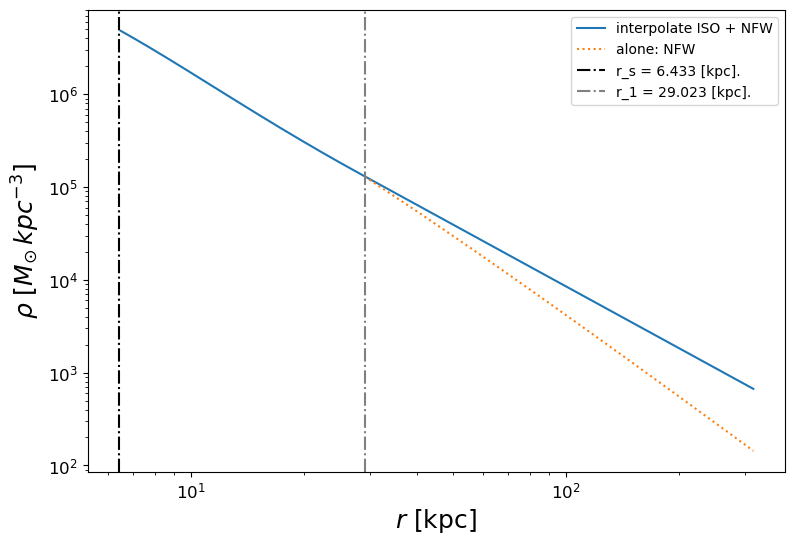

In [12]:
# Plotting
fig, ax = plt.subplots(figsize=(9.0, 6.0))
ax.plot(extra_r, extra_rho, label="interpolate ISO + NFW")
ax.plot(r_NFW, density_m_NFW, label="alone: NFW", linestyle='dotted')
# lines
plt.axvline(x=r_s, color='black', linestyle='dashdot',
                    label=f'r_s = {"{:.3f}".format(r_s)} [kpc].')
plt.axvline(x=r1marge, color='grey', linestyle='dashdot',
                    label=f'r_1 = {"{:.3f}".format(r1marge)} [kpc].')
# log scale
ax.set_xscale('log')
ax.set_yscale('log')
# describe NFW profile
plt.ylabel(r"$\rho \, \, [M_{\odot} \, kpc^{-3}]$", fontsize=18)
plt.xlabel(r"$r$ [kpc]", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()
plt.show()

In [13]:
"""
Above we can see that the density profile is different after evolution than before the evolution
(when I say evolution I thinking about Isothermall evolution). In literature poeple, suprise
surprise do such thinks, so we now exactly to what we have to fit merge. In the next cell I show that
"""

'\nAbove we can see that the density profile is different after evolution than before the evolution\n(when I say evolution I thinking about Isothermall evolution). In literature poeple, suprise\nsurprise do such thinks, so we now exactly to what we have to fit merge. In the next cell I show that\n'

# Denisty profile after evolution

In [14]:
"""
firstly I have to prepare the interpolate density profile in linespace
"""
def rho_interp_simple(old_r, old_rho, new_r):
    """
    """
    density_interp_func = interp1d(old_r, old_rho, kind='linear', fill_value="extrapolate")
    density_interp = density_interp_func(new_r)
    return density_interp

def set_rho_interpolation_linear(old_r, old_rho, new_beg, new_end, step):
    """
    """
    num = int((new_end - new_beg) / step)
    # radius
    rinterp_list = np.linspace(new_beg, new_end, num, endpoint=True)  # [kpc]
    # density
    rhointerp = rho_interp_simple(old_r, old_rho, rinterp_list)  # [M_sun/kpc^3]
    return [rinterp_list,rhointerp] # [M_sun/kpc^3]

old_r = radius_m_ISO
old_rho = density_m_ISO
new_beg = radius_m_ISO[0]
new_end = r_NFW[-1]
print('new_beg:',new_beg, 'new_end:', new_end)
step = 0.001  # [kpc]

new_r_ISO, new_rho_ISO = set_rho_interpolation_linear(old_r, old_rho, new_beg, new_end, step)

print('len(new_r_ISO)', len(new_r_ISO))
print('len(new_rho_ISO)', len(new_rho_ISO))

new_beg: 0.31622776601683794 new_end: 316.22776601683796
len(new_r_ISO) 315911
len(new_rho_ISO) 315911


In [15]:
num = 20 * Nr_ISO
new_r_ISO, new_rho_ISO = set_rho_interpolation(old_r, old_rho, new_beg, new_end, num)

In [16]:
"""
rho_after(r, rho_NFW, r_c):
    return rho_NFW * np.tanh(r / r_c)
    
rho_fit = rho_after(r, rho_NFW, r_c) / rho_NFW = np.tanh(r / r_c)

method{‘lm’, ‘trf’, ‘dogbox’}, optional

"""
density_NFW = NFW_profile.rho(new_r_ISO)
print('len(density_NFW):', len(density_NFW))
prepare_rho = np.array([])
for i in range(0, len(new_r_ISO)):
    density = new_rho_ISO[i] / density_NFW[i]
    prepare_rho = np.append(prepare_rho, density)
    
print('len(prepare_rho):', len(prepare_rho))


def rho_fit(r, r_c):
    """
    is a density profile, after evolution
    """
    return np.tanh(r / r_c)

fitting_parameters, covariance = curve_fit(rho_fit, new_r_ISO, prepare_rho, method='lm')
c_r = fitting_parameters

print('c_r:', c_r)
print('covariance:', covariance)

# c_r = 3.0
# print('c_r:', c_r)


def real_rho_profile(rho_NFW, r, _c_r):
    return rho_NFW * np.tanh(r/_c_r)

real_rho_profile = np.array(real_rho_profile(density_NFW, new_r_ISO, c_r))

len(density_NFW): 7840
len(prepare_rho): 7840
c_r: [1.94105908]
covariance: [[0.01074656]]


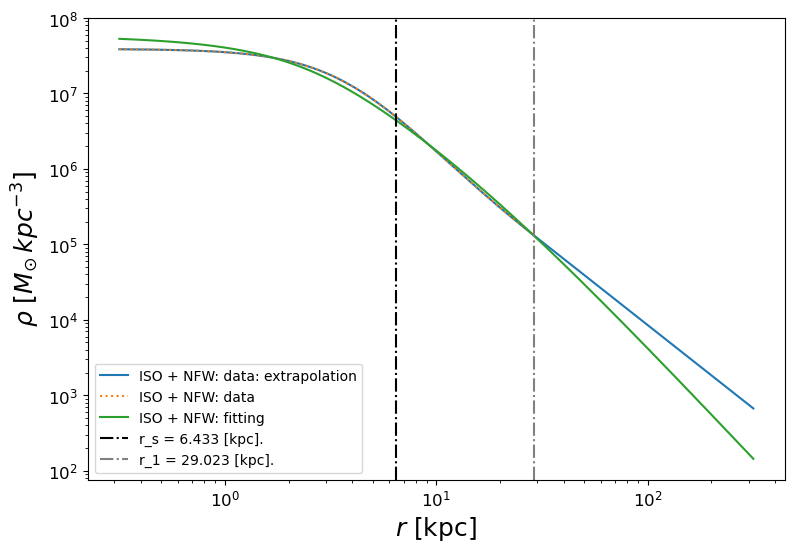

In [17]:
# Plotting
fig, ax = plt.subplots(figsize=(9.0, 6.0))
ax.plot(new_r_ISO, new_rho_ISO, label="ISO + NFW: data: extrapolation")
ax.plot(radius_m_ISO, density_m_ISO, label="ISO + NFW: data", linestyle='dotted')
ax.plot(new_r_ISO, real_rho_profile, label="ISO + NFW: fitting")
# lines
plt.axvline(x=r_s, color='black', linestyle='dashdot',
                    label=f'r_s = {"{:.3f}".format(r_s)} [kpc].')
plt.axvline(x=r1marge, color='grey', linestyle='dashdot',
                    label=f'r_1 = {"{:.3f}".format(r1marge)} [kpc].')
# log scale
ax.set_xscale('log')
ax.set_yscale('log')
# describe NFW profile
plt.ylabel(r"$\rho \, \, [M_{\odot} \, kpc^{-3}]$", fontsize=18)
plt.xlabel(r"$r$ [kpc]", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()
plt.show()

In [18]:
c_r = aux.find_fitting_parm(NFW_profile, radius_m_ISO, density_m_ISO)
print(c_r)

[1.94090374]


In [19]:
nums_r = 600
r_s = 6.433
r = np.logspace(-0.5,2.5, nums_r)

index = -1
for i in range(0, nums_r):
    if r_s < r[i]:
        index=i
        break
        
print(index)

262
